# 1. Business understanding  

The goal is to create optimal model to predict diabetes based on questionnaire. We try to find optimal model for this specific questionnaire using logistic regression and randomsearch forest.

# 2. Data understanding

The dataset contains health, lifestyle, and demographic information that can be used to study diabetes. The target variable indicates whether an individual has diabetes or prediabetes.

In [1]:
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
# fetch dataset 
cdc_diabetes_health_indicators = fetch_ucirepo(id=891) 

# data (as pandas dataframes) 
X = cdc_diabetes_health_indicators.data.features 
y = cdc_diabetes_health_indicators.data.targets
  
# variable information 
print(cdc_diabetes_health_indicators.variables) 


                    name     role     type      demographic  \
0                     ID       ID  Integer              NaN   
1        Diabetes_binary   Target   Binary              NaN   
2                 HighBP  Feature   Binary              NaN   
3               HighChol  Feature   Binary              NaN   
4              CholCheck  Feature   Binary              NaN   
5                    BMI  Feature  Integer              NaN   
6                 Smoker  Feature   Binary              NaN   
7                 Stroke  Feature   Binary              NaN   
8   HeartDiseaseorAttack  Feature   Binary              NaN   
9           PhysActivity  Feature   Binary              NaN   
10                Fruits  Feature   Binary              NaN   
11               Veggies  Feature   Binary              NaN   
12     HvyAlcoholConsump  Feature   Binary              NaN   
13         AnyHealthcare  Feature   Binary              NaN   
14           NoDocbcCost  Feature   Binary             

In [3]:
X.dtypes

HighBP                  int64
HighChol                int64
CholCheck               int64
BMI                     int64
Smoker                  int64
Stroke                  int64
HeartDiseaseorAttack    int64
PhysActivity            int64
Fruits                  int64
Veggies                 int64
HvyAlcoholConsump       int64
AnyHealthcare           int64
NoDocbcCost             int64
GenHlth                 int64
MentHlth                int64
PhysHlth                int64
DiffWalk                int64
Sex                     int64
Age                     int64
Education               int64
Income                  int64
dtype: object

In [4]:
y.dtypes

Diabetes_binary    int64
dtype: object

In [5]:
X.head(10)

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,1,1,1,40,1,0,0,0,0,1,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,25,1,0,0,1,0,0,...,0,1,3,0,0,0,0,7,6,1
2,1,1,1,28,0,0,0,0,1,0,...,1,1,5,30,30,1,0,9,4,8
3,1,0,1,27,0,0,0,1,1,1,...,1,0,2,0,0,0,0,11,3,6
4,1,1,1,24,0,0,0,1,1,1,...,1,0,2,3,0,0,0,11,5,4
5,1,1,1,25,1,0,0,1,1,1,...,1,0,2,0,2,0,1,10,6,8
6,1,0,1,30,1,0,0,0,0,0,...,1,0,3,0,14,0,0,9,6,7
7,1,1,1,25,1,0,0,1,0,1,...,1,0,3,0,0,1,0,11,4,4
8,1,1,1,30,1,0,1,0,1,1,...,1,0,5,30,30,1,0,9,5,1
9,0,0,1,24,0,0,0,0,0,1,...,1,0,2,0,0,0,1,8,4,3


In [6]:
import matplotlib.pyplot as plt

def plot_data(X):
    plt.figure(figsize=(20, 15))

    for i, col in enumerate(X.select_dtypes(include=['int', 'float'])):
        plt.subplot(5, 5, i + 1)
        X[col].plot(kind='hist', title=col)
        plt.xlabel(col)

    plt.tight_layout()
    plt.show()

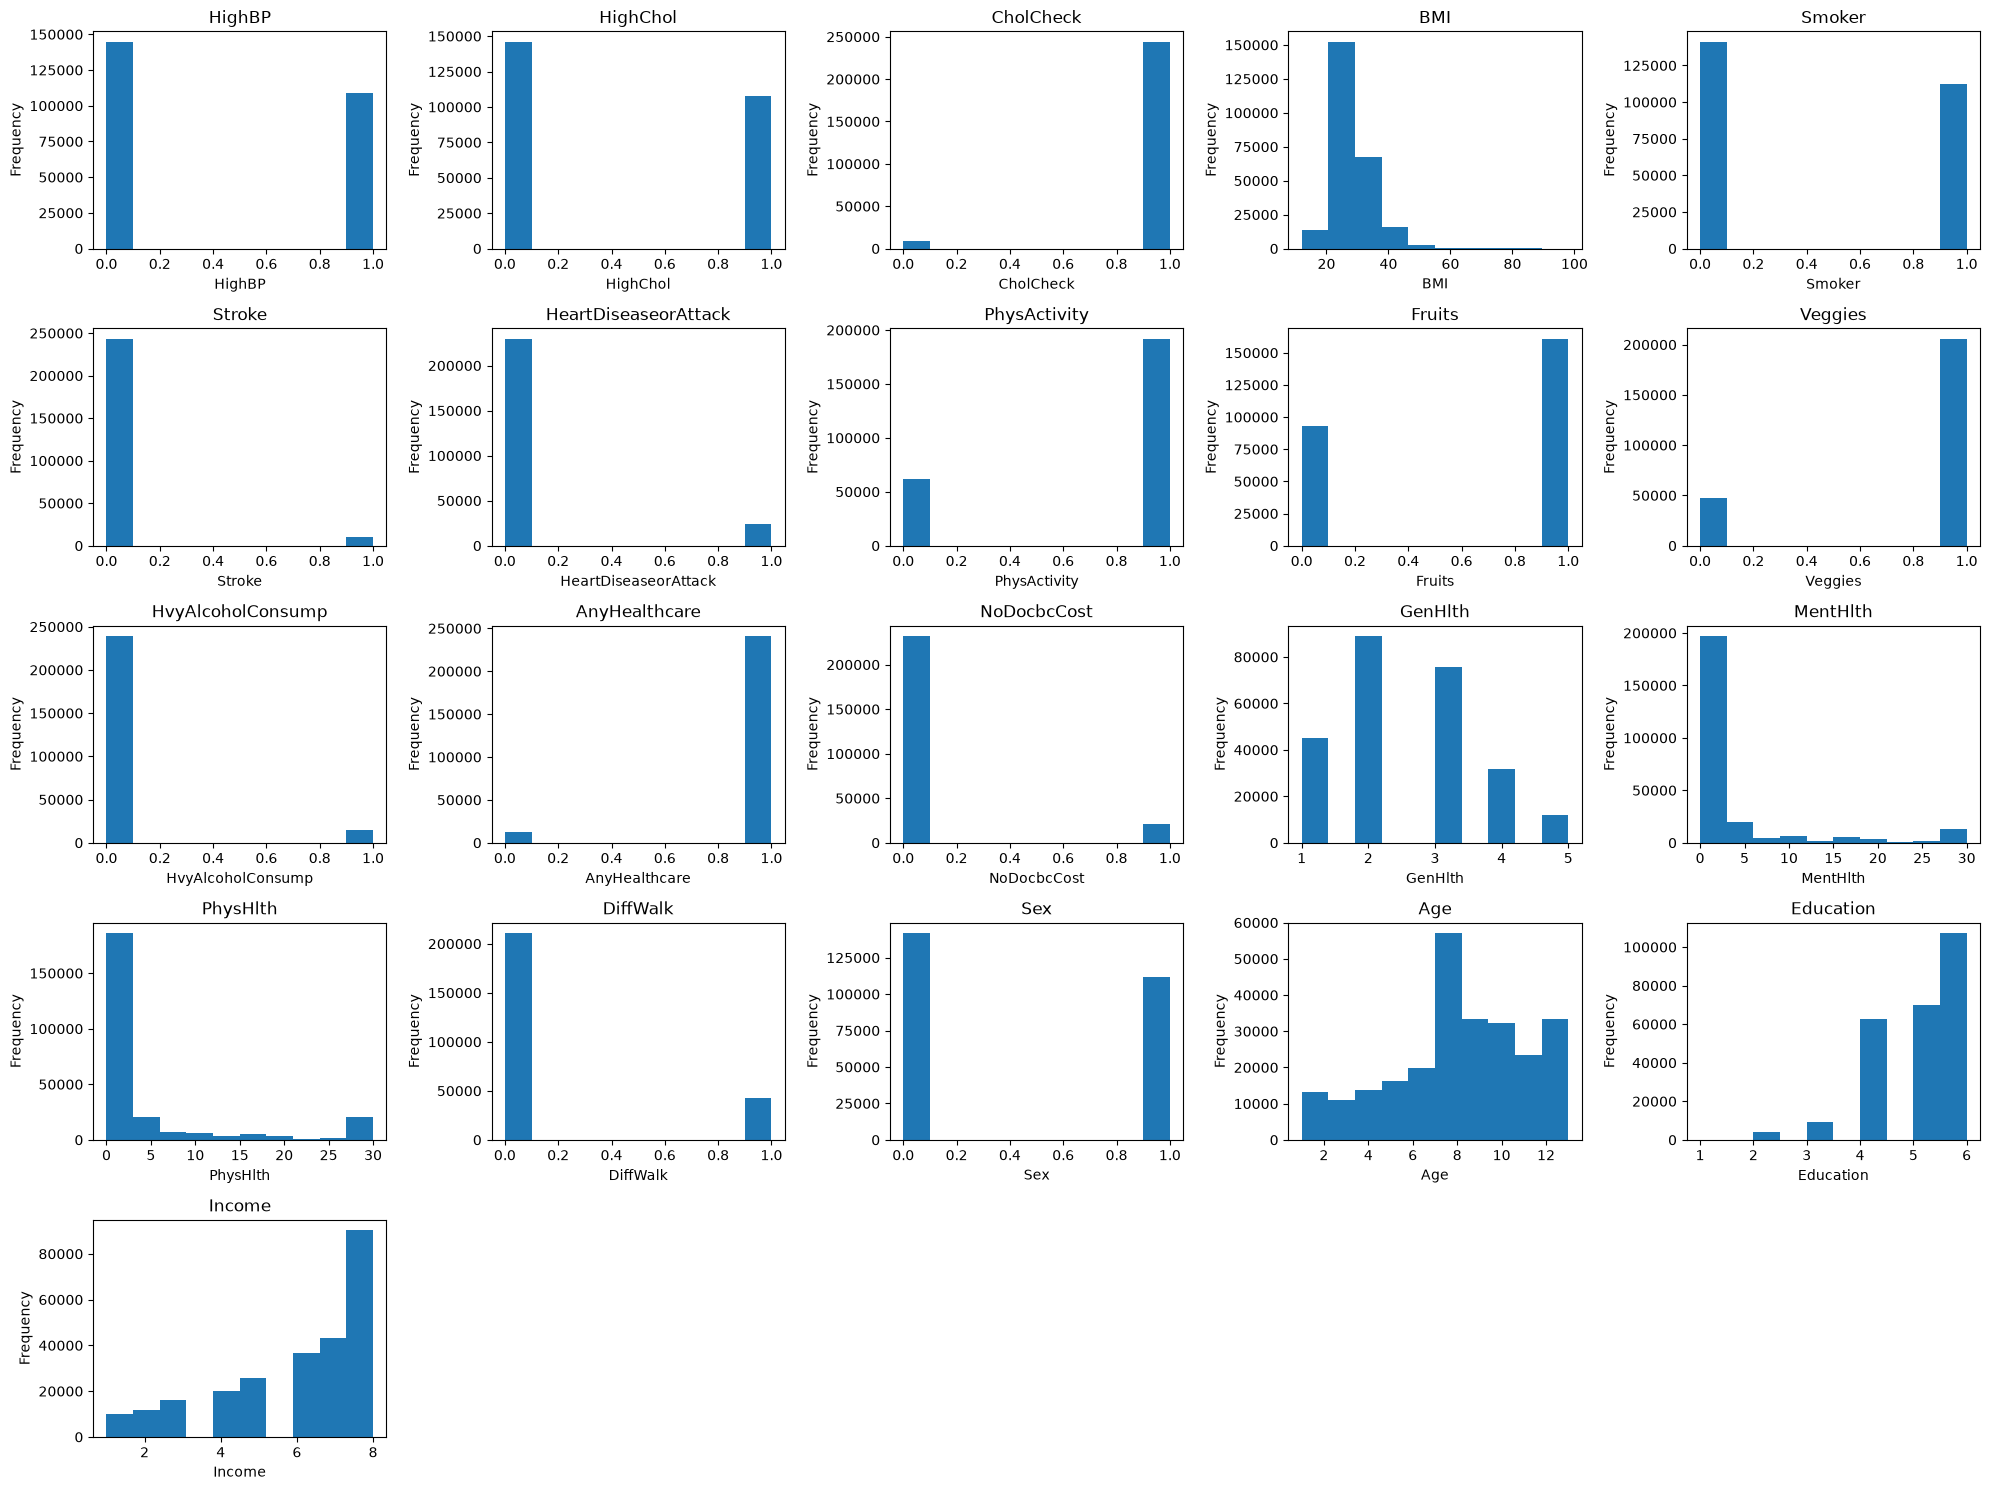

In [7]:
plot_data(X)

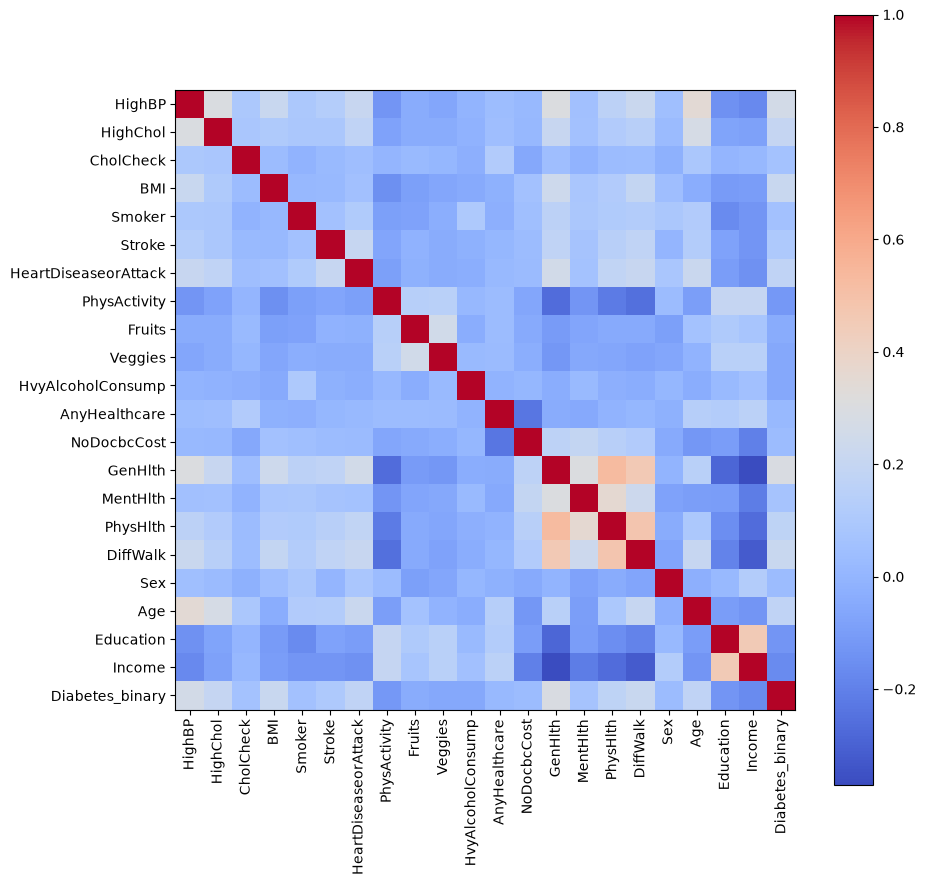

In [8]:
#correlation matrix
df = pd.concat([X, y], axis=1)

corr = df.corr()

plt.figure(figsize=(10, 10))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.show()

## Conclusion

There is multiple colums. All of them are based on query and most of them are binary *`Yes`* / *`No`* based or sex such as *`Diabetes_binary`*, *`HighBP`*, *`HighChol`*, *`CholCheck`*, *`Smoker`*, *`Stroke`*, *`HeartDiseaseorAttack`*, *`PhysActivity`*, *`Fruits`*, *`Veggies`*, *`HvyAlcoholConsump`*, *`AnyHealthcare`*, *`NoDocbcCost`*, *`DiffWalk`* and *`Sex`*. Multiple options were on *`BMI`*, *`GenHlth`*, *`MentHlth`*, *`PhysHlth`*, *`Age`*, *`Education`* and *`Income`*.

Heatmap indicates some correlation between *`Diabetes_binary`* and *`HighBP`*, *`HighChol`*, *`BMI`*, *`HeartDiseaseorAttack`*, *`GenHlth`*, *`PhysHlth`*, *`DiffWalk`* and *`Age`*. The strongest positive correlations appear to be with *`GenHlth`*, *`HighBP`* and *`BMI`*. There are also weaker negative correlations with variables such as *`PhysActivity`*, *`Education`* and *`Income`*.

# 3. Data preparation

Lets check datas empty values first.

In [9]:
X.isna().sum()

HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [10]:
y.isna().sum()

Diabetes_binary    0
dtype: int64

No empty values in data set and no outliers because data is based on questionnaire.

## Data preparation for logical regression

The data was split into training and testing sets. The features were also standardized to ensure that they are on a comparable scale. This is useful for logistic regression and makes the model coefficients easier to compare. Shape of y needs to be changed from 2D column vector to 1D vector.

In [11]:
y_logistic = y.squeeze()

X_logistic = X

X_train, X_test, y_train, y_test = train_test_split(
    X_logistic,
    y_logistic,
    test_size=0.2,
    random_state=123,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Modeling

A logistic regression model was trained using the training data to predict if an individual has diabetes or prediabetes.

In [12]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)

# 5. Evaluation

## Logistic regression model

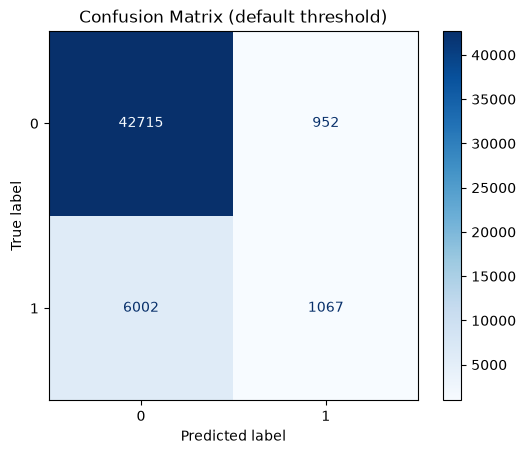

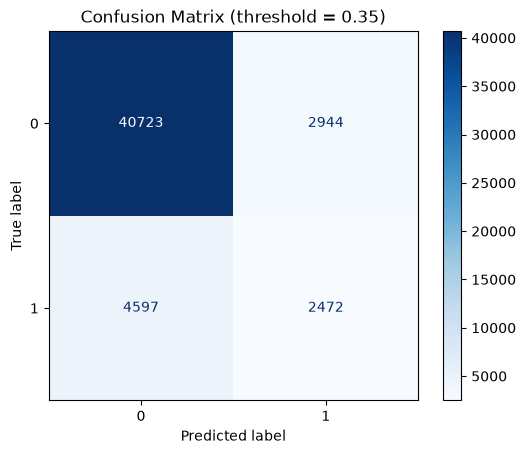

In [13]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (default threshold)")
plt.show()


y_prob = logistic_model.predict_proba(X_test)[:, 1]

threshold = 0.35
y_pred_new = (y_prob >= threshold).astype(int)

cm2 = confusion_matrix(y_test, y_pred_new)

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2)
disp2.plot(cmap="Blues")
plt.title("Confusion Matrix (threshold = 0.35)")
plt.show()

### Conclusion

The default threshold produces *`952`* false positives and *`6002`* false negatives. This means that relatively few non-diabetic individuals are incorrectly classified as diabetic, but a large number of diabetic individuals are missed by the model.

When the threshold is lowered to *`0.35`*, false negatives decrease from *`6002`* to *`4597`*, while false positives increase from *`952`* to *`2944`*. Therefore, lowering the threshold improves the model's ability to detect diabetes, but at the cost of incorrectly classifying more non-diabetic individuals as diabetic.

In this case, the number of false negatives decreases by *`1405`*, while false positives increase by *`1992`*. For diabetes prediction, reducing false negatives can be more important because missing a person who may have diabetes is generally more serious than incorrectly identifying someone as potentially diabetic.